### EDA

In [144]:
#### Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import seaborn as sns
# sns.pairplot = good visualizations
import os
from sklearn.cluster import KMeans

#### Data path
data_path = os.path.join(
    'Data',
)

#### Reading data - prices
df_prices = pd.read_csv(
    f'{data_path}/clean_top40.csv',
    parse_dates=['Date'],
    index_col='Date'
)
stocks = df_prices.columns

#### Creating return data
# df_returns = df_prices.pct_change()
df_returns = np.log(df_prices/df_prices.shift(1)).dropna()

### Visual hyerparameters
WIDTH = 8
HEIGHT = 6

In [145]:
#### Overview summary
### Prices
df_prices_stats = df_prices.describe().round(3)
df_prices_stats.loc['current'] = df_prices.iloc[-1].round(3)
prices_overview = df_prices_stats.loc[['current','mean','std']].T\
    .sort_values(by='current', ascending=False)


### Returns
df_returns_stats = df_returns.describe().round(3)
df_returns_stats.loc['latest'] = df_returns.iloc[-1].round(3)
returns_overview = df_returns_stats.loc[['latest', 'mean', 'std']].T\
    .sort_values(by='latest', ascending=False)

display(prices_overview)
display(returns_overview)


,current,mean,std
ISA.CL,29100.000,9644.654,6167.913
FALABELLA.SN,5835.000,3273.792,1278.353
CENCOSUD.SN,1995.000,1279.243,542.325
BAP,402.270,97.900,63.495
FEMSAUBD.MX,219.700,101.918,51.147
PAC,219.580,71.274,63.766
GMEXICOB.MX,211.552,44.033,40.151
GFNORTEO.MX,200.900,61.681,42.076
AC.MX,196.559,78.669,52.466
SCCO,185.000,36.767,35.825


,latest,mean,std
SCCO,0.053,0.001,0.026
CIB,0.048,0.000,0.022
BAP,0.047,0.001,0.020
FEMSAUBD.MX,0.039,0.000,0.016
AXIA3.SA,0.035,0.000,0.029
ITUB,0.035,0.000,0.027
SBSP3.SA,0.030,0.001,0.023
PBR,0.028,0.000,0.032
WEGE3.SA,0.026,0.001,0.021
BSAC,0.025,0.000,0.020


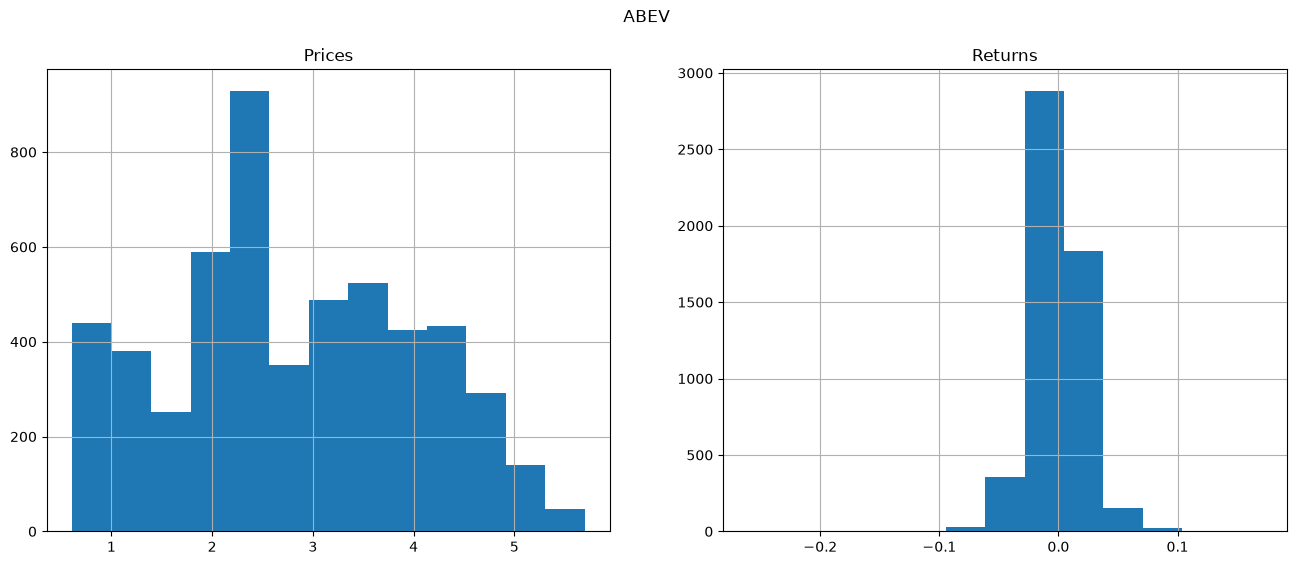

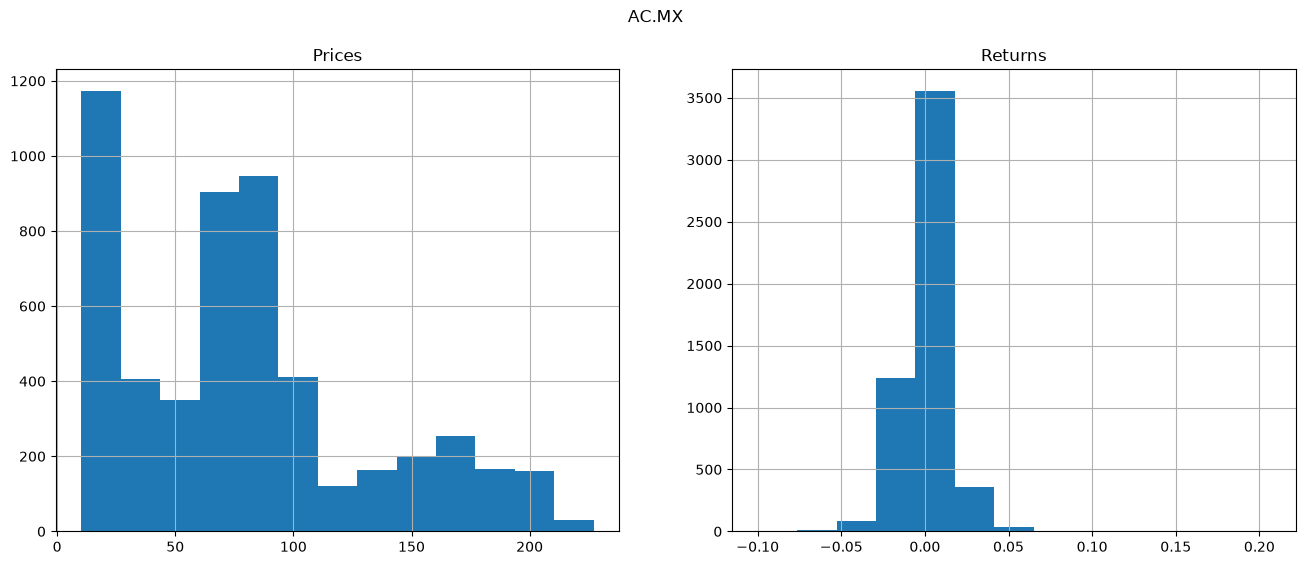

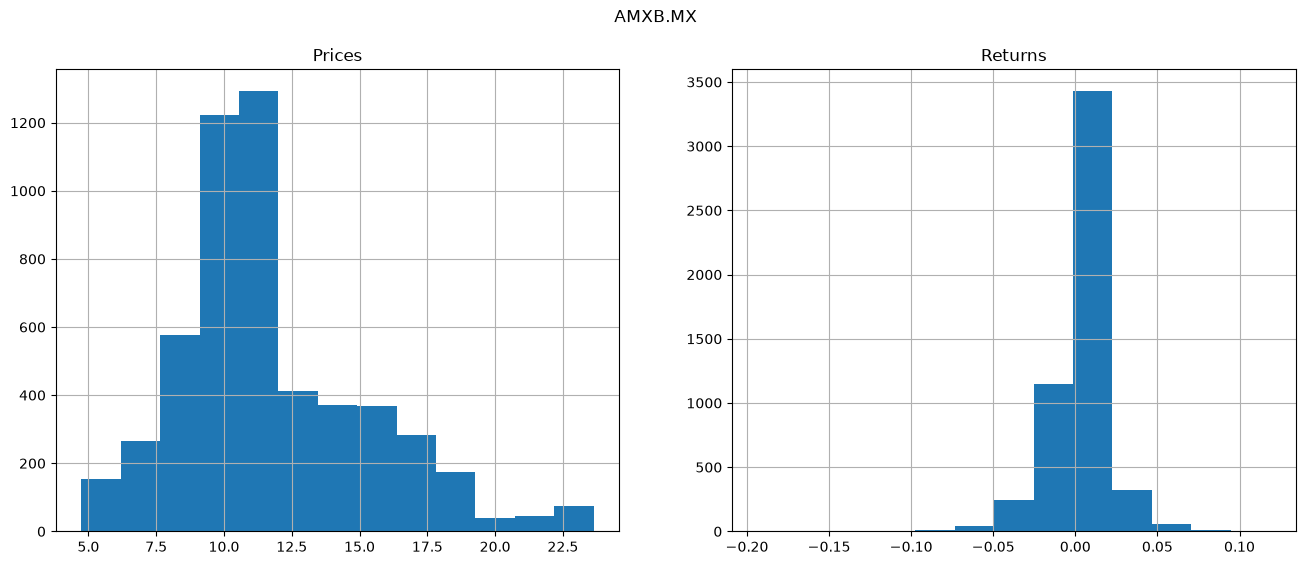

In [146]:
#### Histograms
num_bins = int(1 + (np.log(df_prices.shape[0])/np.log(2)))  #Sturges law
num_cols = 2
num_rows = 1
for i, col in enumerate(df_prices.columns):
    fig, axs = plt.subplots(ncols=num_cols, nrows=num_rows, figsize=(WIDTH * num_cols, HEIGHT * num_rows))
    df_prices[col].hist(ax = axs[0], bins=num_bins)
    axs[0].set_title('Prices')
    df_returns[col].hist(ax = axs[1], bins = num_bins)
    axs[1].set_title('Returns')
    fig.suptitle(f'{col}')
    plt.show()
    if i == 2: break


In [147]:
#### Creating function to analyze historical price correlations
def np_hist_corr(df_prices: pd.DataFrame, df_returns: pd.DataFrame, periods:list[str]):
    np_prices_hist_corr = np.zeros((len(periods), df_prices.shape[1], df_prices.shape[1]), dtype=float)
    np_returns_hist_corr= np.zeros((len(periods), df_returns.shape[1], df_returns.shape[1]), dtype=float)

    ### Prices
    ## All
    np_prices_hist_corr[0] = df_prices.corr()
    ## 10 years
    np_prices_hist_corr[1] = df_prices[df_prices.index > "2016-07-31"].corr()
    ## 5 years
    np_prices_hist_corr[2] = df_prices[df_prices.index > "2021-07-31"].corr()
    ## 1 year
    np_prices_hist_corr[3] = df_prices[df_prices.index > "2025-07-31"].corr()
    ## 6 months
    np_prices_hist_corr[4] = df_prices[df_prices.index > "2026-01-31"].corr()
    ## 3 months
    np_prices_hist_corr[5] = df_prices[df_prices.index > "2026-04-30"].corr()

    ### Returns
    ## All
    np_returns_hist_corr[0] = df_returns.corr()
    ## 10 years
    np_returns_hist_corr[1] = df_returns[df_returns.index > "2016-07-31"].corr()
    ## 5 years
    np_returns_hist_corr[2] = df_returns[df_returns.index > "2021-07-31"].corr()
    ## 1 year
    np_returns_hist_corr[3] = df_returns[df_returns.index > "2025-07-31"].corr()
    ## 6 months
    np_returns_hist_corr[4] = df_returns[df_returns.index > "2026-01-31"].corr()
    ## 3 months
    np_returns_hist_corr[5] = df_returns[df_returns.index > "2026-04-30"].corr()

    return np_prices_hist_corr, np_returns_hist_corr


In [148]:
#### Creating NP 3D array for historical price correlations
    # Histories: all, 10 years, 5 year, 1 year, 6 months, 3 months - 6 periods
    # Recall: data date range: 2/27/26 - 7/31/26
### Initialization
periods = ['All', '10 years', '5 years', '1 year', '6 months', '3 months']
np_prices_hist_corr, np_returns_hist_corr = \
    np_hist_corr(df_prices, df_returns, periods)

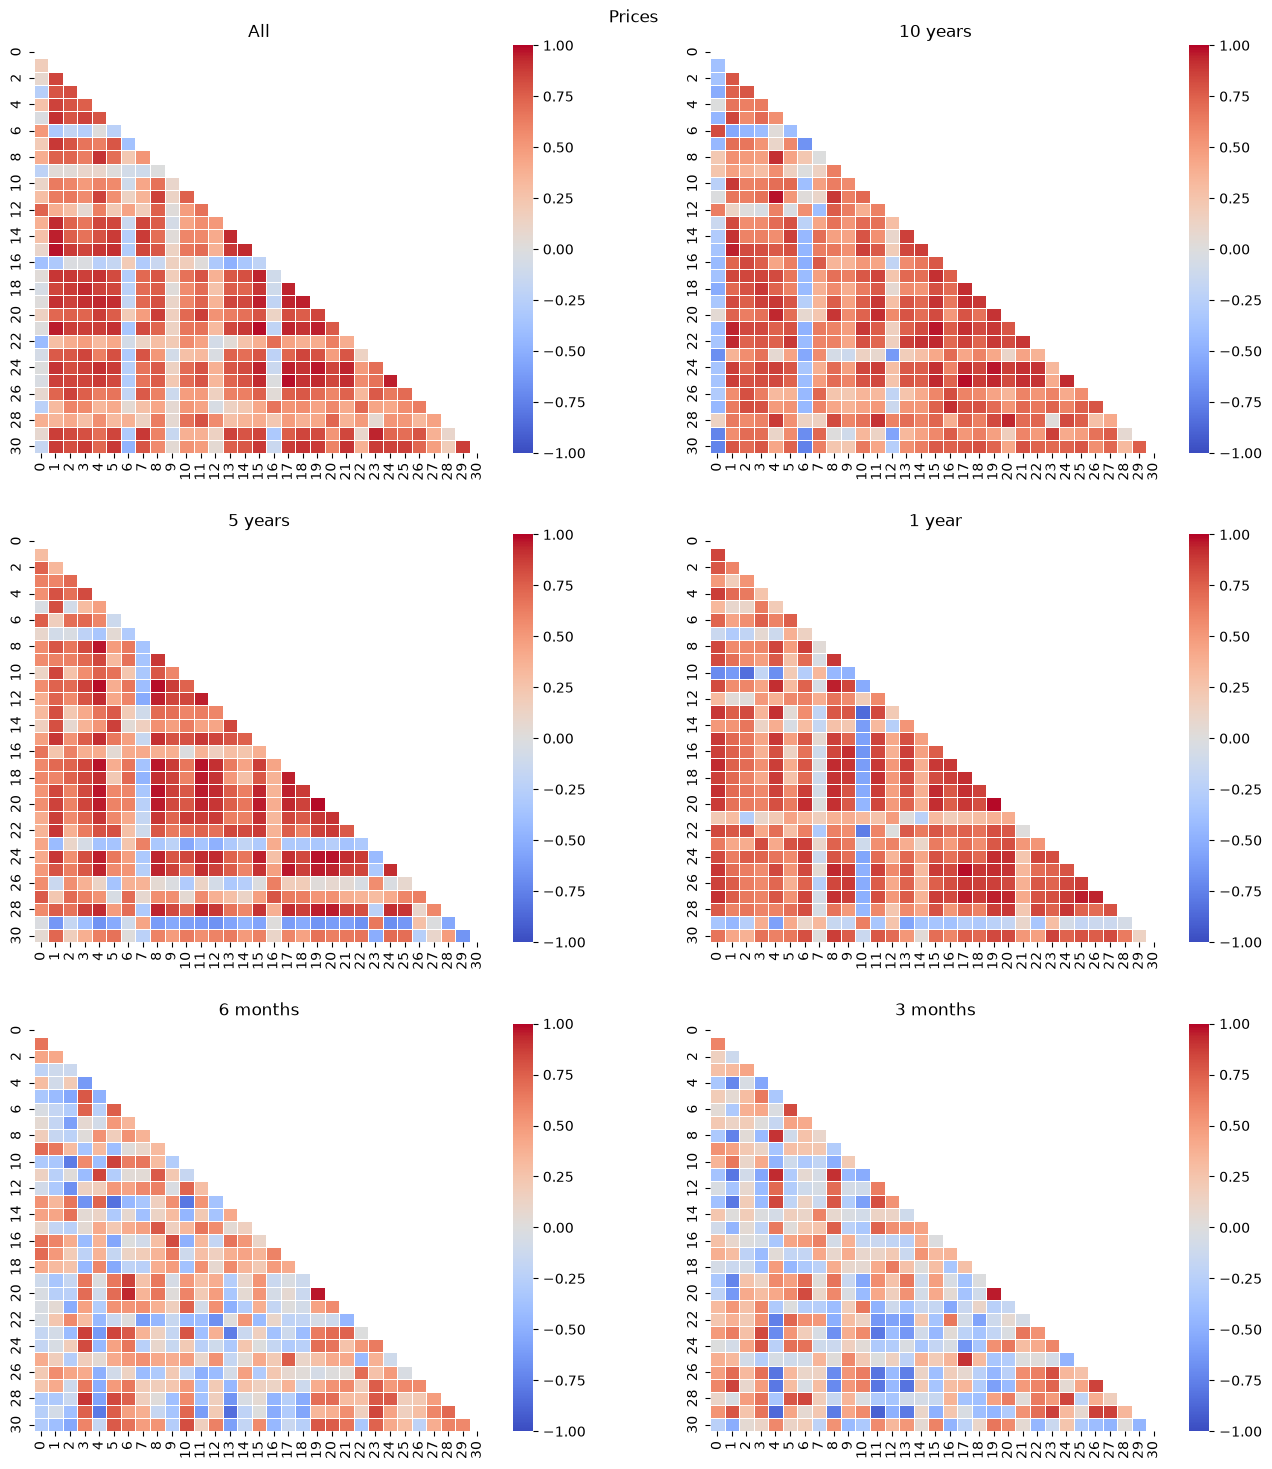

In [149]:
#### Historic Correlation - Prices 
num_cols = 2
num_rows = 3
fig, axs = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(WIDTH * num_cols, HEIGHT * num_rows))
axs_arr = [axs[0,0], axs[0,1], axs[1,0], axs[1,1], axs[2,0], axs[2,1]]
for i, period_corr in enumerate(np_prices_hist_corr):
    mask = np.zeros_like(period_corr, dtype=np.bool)
    mask[np.triu_indices_from(mask)] = True
    sns.heatmap(
        period_corr,
        ax = axs_arr[i],
        annot=False,
        cmap='coolwarm',
        linewidths=0.5,
        vmin=-1, vmax=1,
        mask=mask
    )
    axs_arr[i].set_title(f'{periods[i]}')
    # axs_arr[i].set_xticklabels(stocks)
fig.suptitle(f'Prices', y=0.9)
plt.show()


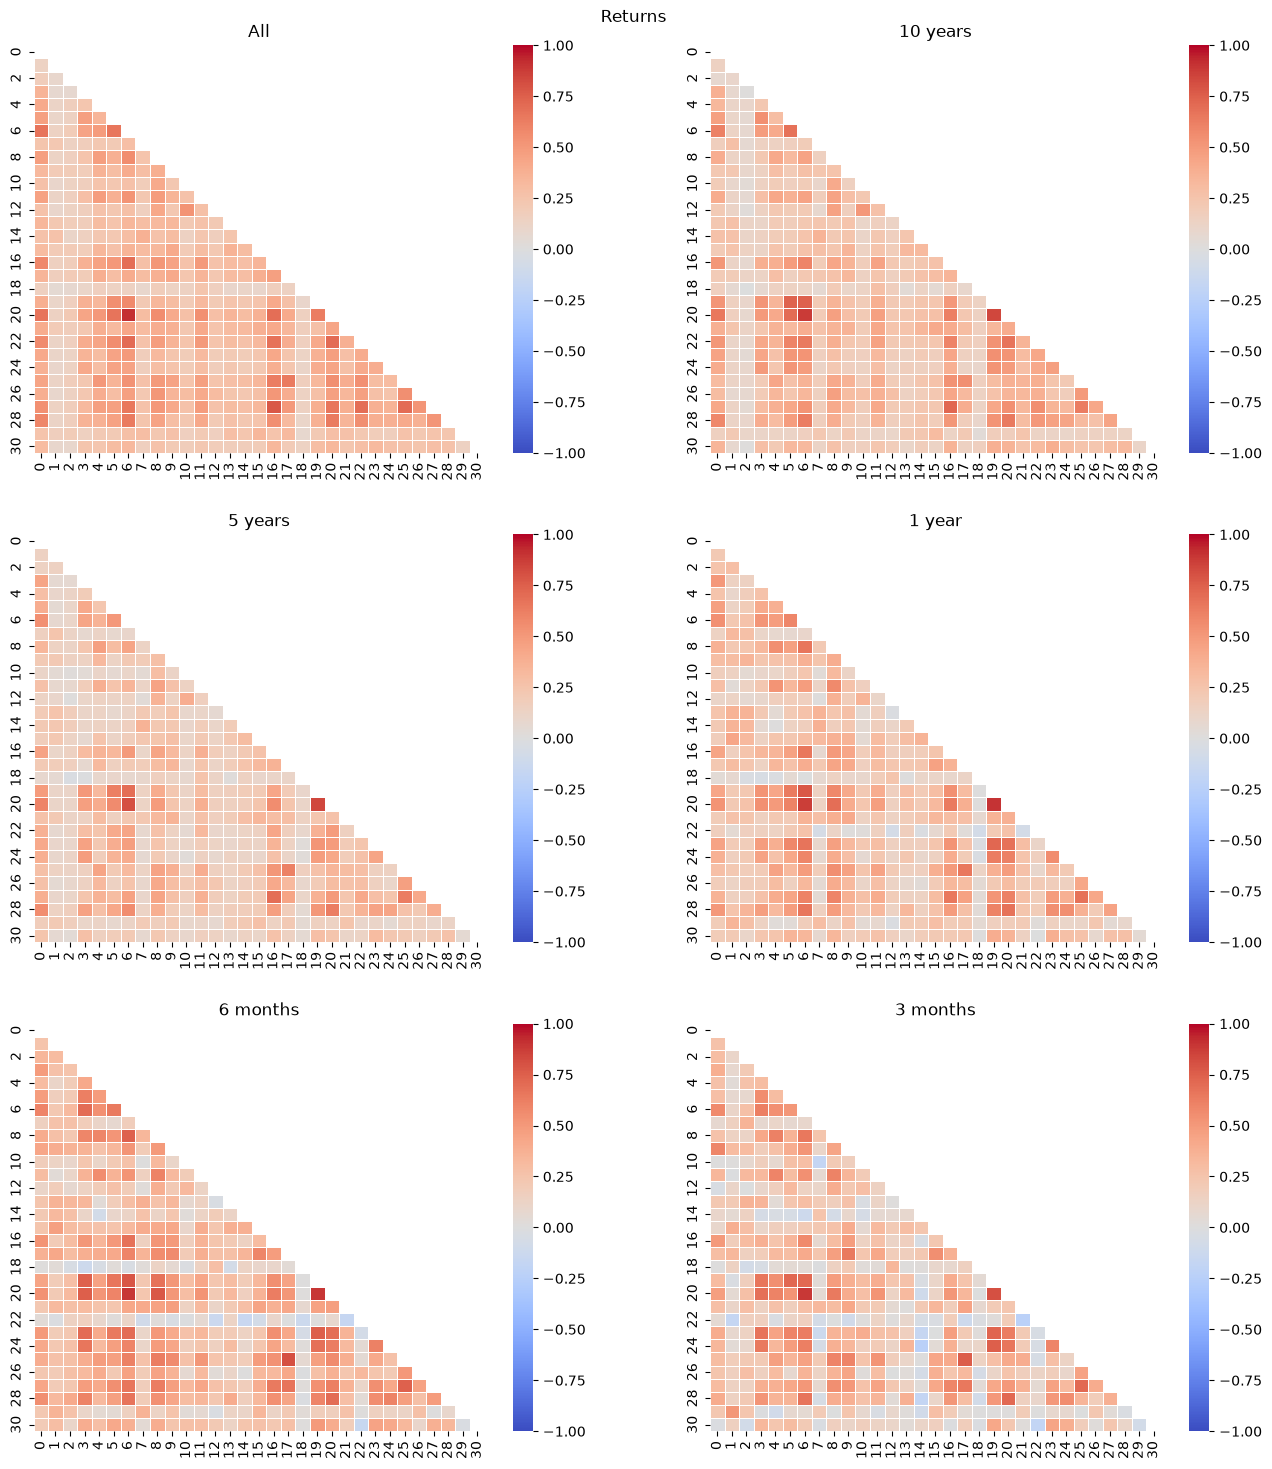

In [150]:
#### Historic Correlation - Returns 
num_cols = 2
num_rows = 3
fig, axs = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(WIDTH * num_cols, HEIGHT * num_rows))
axs_arr = [axs[0,0], axs[0,1], axs[1,0], axs[1,1], axs[2,0], axs[2,1]]
for i, period_corr in enumerate(np_returns_hist_corr):
    mask = np.zeros_like(period_corr, dtype=np.bool)
    mask[np.triu_indices_from(mask)] = True
    sns.heatmap(
        period_corr,
        ax = axs_arr[i],
        annot=False,
        cmap='coolwarm',
        linewidths=0.5,
        vmin=-1, vmax=1,
        mask=mask
    )
    axs_arr[i].set_title(f'{periods[i]}')
    # axs_arr[i].set_xticklabels(stocks)
fig.suptitle(f'Returns', y=0.9)
plt.show()

In [151]:
#### Funcion para identificar correlaciones encima de un valor
def corr_thres(corrs_arr : np.ndarray, stock_names : list[str], thresh: float, period : str):
    df_corr = pd.DataFrame(
        corrs_arr,
        columns=stock_names,
        index=stock_names
    )
    df_corr[((df_corr < thresh) & (df_corr > -thresh))] = np.nan
    df_corr[df_corr.notna()] = 1
    df_corr = df_corr.fillna(0)
    return df_corr


In [152]:
#### Counting high correlations across periods
### Creating Dataframes
df_prices_corr_gt_thresh = pd.DataFrame(
    columns=periods,
    index=stocks
)
df_returns_corr_gt_thres =  pd.DataFrame(
    columns=periods,
    index=stocks
)

### Creating correlations
THRESH = 0.8
for np_price, np_return, period in zip(np_prices_hist_corr, np_returns_hist_corr, periods):
    tmp = corr_thres(np_price, stocks, THRESH, f"Prices - {period}")
    df_prices_corr_gt_thresh[period] = tmp.sum().sort_values(ascending=False)
    del tmp
    tmp = corr_thres(np_return, stocks, THRESH, f"Prices - {period}")
    df_returns_corr_gt_thres[period] = tmp.sum().sort_values(ascending=False)
    del tmp

### Investigating results
display(df_prices_corr_gt_thresh.sort_values(by='All', ascending=False))
display(df_returns_corr_gt_thres.sort_values(by='All', ascending=False))



,All,10 years,5 years,1 year,6 months,3 months
ITSA4.SA,18.0,14.0,17.0,17.0,3.0,2.0
GFNORTEO.MX,17.0,16.0,16.0,13.0,1.0,1.0
PAC,17.0,14.0,14.0,1.0,1.0,1.0
AC.MX,16.0,12.0,11.0,2.0,1.0,3.0
GMEXICOB.MX,15.0,13.0,15.0,16.0,1.0,2.0
BBAS3.SA,15.0,6.0,4.0,2.0,5.0,2.0
ISA.CL,15.0,10.0,13.0,15.0,1.0,1.0
SBSP3.SA,15.0,15.0,17.0,12.0,2.0,2.0
SCCO,14.0,14.0,15.0,16.0,1.0,2.0
WEGE3.SA,14.0,3.0,1.0,8.0,2.0,1.0


,All,10 years,5 years,1 year,6 months,3 months
BBD,2.0,2.0,2.0,2.0,2.0,2.0
ITUB,2.0,3.0,3.0,3.0,3.0,3.0
AC.MX,1.0,1.0,1.0,1.0,1.0,1.0
AMXB.MX,1.0,1.0,1.0,1.0,1.0,1.0
AXIA3.SA,1.0,1.0,1.0,1.0,1.0,1.0
BAP,1.0,1.0,1.0,1.0,1.0,1.0
ABEV,1.0,1.0,1.0,1.0,1.0,1.0
BIMBOA.MX,1.0,1.0,1.0,1.0,1.0,1.0
BSAC,1.0,1.0,1.0,1.0,1.0,1.0
CEMEXCPO.MX,1.0,1.0,1.0,1.0,1.0,1.0


In [153]:
#### Erasing high correlated actions
### Prices dataframe
## Choosing max number of highly correlated actions 
prices_max_hc_actions = 15
actions_to_erase = set()
## Selecting actions
for col in df_prices_corr_gt_thresh.columns:
    selected_actions = df_prices_corr_gt_thresh[
            df_prices_corr_gt_thresh[col] > prices_max_hc_actions
        ].index.to_list()
    if len(selected_actions) > 1: selected_actions.pop()  
    # All highly correlated erased except for 1 
            # to avoid erasing all information
    actions_to_erase.update(selected_actions)
print(actions_to_erase)
### Returns datarame
returns_max_hc_actions = 1
for col in df_returns_corr_gt_thres.columns:
    selected_actions = df_returns_corr_gt_thres[
            df_returns_corr_gt_thres[col] > returns_max_hc_actions
        ].index.to_list()
    if len(selected_actions) > 1: selected_actions.pop()  
    # All highly correlated erased except for 1 
            # to avoid erasing all information
    actions_to_erase.update(selected_actions)
print(actions_to_erase)


### Deleting actions
df_prices_no_hc = df_prices.drop(columns=actions_to_erase)
print(df_prices_no_hc.shape)
### Recreating df_returns
df_returns_no_hc = np.log(df_prices_no_hc/df_prices_no_hc.shift(1))

### Guardando nuevos datos
df_prices_no_hc.to_csv(f"{data_path}/filtered_top40.csv", index=True, encoding='utf-8')

{'SCCO', 'ITUB', 'GFNORTEO.MX', 'SBSP3.SA', 'ABEV', 'BSAC', 'BAP', 'AC.MX', 'ITSA4.SA', 'GMEXICOB.MX'}
{'SCCO', 'ITUB', 'GFNORTEO.MX', 'SBSP3.SA', 'ABEV', 'BSAC', 'BAP', 'AC.MX', 'ITSA4.SA', 'BBD', 'GMEXICOB.MX'}
(5285, 20)


In [154]:
#### Rechecking correlations
### Creating hsitorical dfs
periods = ['All', '10 years', '5 years', '1 year', '6 months', '3 months']
stocks = df_prices_no_hc.columns
np_prices_hist_corr, np_returns_hist_corr = \
    np_hist_corr(df_prices_no_hc, df_returns_no_hc, periods)

### Creating Dataframes
df_prices_corr_gt_thresh = pd.DataFrame(
    columns=periods,
    index=stocks
)
df_returns_corr_gt_thres =  pd.DataFrame(
    columns=periods,
    index=stocks
)

### Creating correlations
THRESH = 0.8
for np_price, np_return, period in zip(np_prices_hist_corr, np_returns_hist_corr, periods):
    tmp = corr_thres(np_price, stocks, THRESH, f"Prices - {period}")
    df_prices_corr_gt_thresh[period] = tmp.sum().sort_values(ascending=False)
    del tmp
    tmp = corr_thres(np_return, stocks, THRESH, f"Prices - {period}")
    df_returns_corr_gt_thres[period] = tmp.sum().sort_values(ascending=False)
    del tmp

### Investigating results
display(df_prices_corr_gt_thresh.sort_values(by='All', ascending=False))
display(df_returns_corr_gt_thres.sort_values(by='All', ascending=False))

,All,10 years,5 years,1 year,6 months,3 months
PAC,10.0,8.0,5.0,1.0,1.0,1.0
WALMEX.MX,10.0,2.0,1.0,1.0,3.0,5.0
BBAS3.SA,9.0,4.0,3.0,2.0,5.0,1.0
AXIA3.SA,8.0,3.0,4.0,2.0,3.0,2.0
ISA.CL,8.0,5.0,6.0,7.0,1.0,1.0
WEGE3.SA,8.0,3.0,1.0,3.0,2.0,1.0
AMXB.MX,7.0,6.0,1.0,4.0,1.0,1.0
RENT3.SA,6.0,2.0,1.0,5.0,4.0,4.0
FEMSAUBD.MX,6.0,4.0,3.0,6.0,4.0,3.0
BIMBOA.MX,5.0,1.0,1.0,1.0,1.0,1.0


,All,10 years,5 years,1 year,6 months,3 months
AMXB.MX,1.0,1.0,1.0,1.0,1.0,1.0
AXIA3.SA,1.0,1.0,1.0,1.0,1.0,1.0
BBAS3.SA,1.0,1.0,1.0,1.0,1.0,1.0
BIMBOA.MX,1.0,1.0,1.0,1.0,1.0,1.0
CEMEXCPO.MX,1.0,1.0,1.0,1.0,1.0,1.0
CENCOSUD.SN,1.0,1.0,1.0,1.0,1.0,1.0
CIB,1.0,1.0,1.0,1.0,1.0,1.0
FALABELLA.SN,1.0,1.0,1.0,1.0,1.0,1.0
FEMSAUBD.MX,1.0,1.0,1.0,1.0,1.0,1.0
GCARSOA1.MX,1.0,1.0,1.0,1.0,1.0,1.0


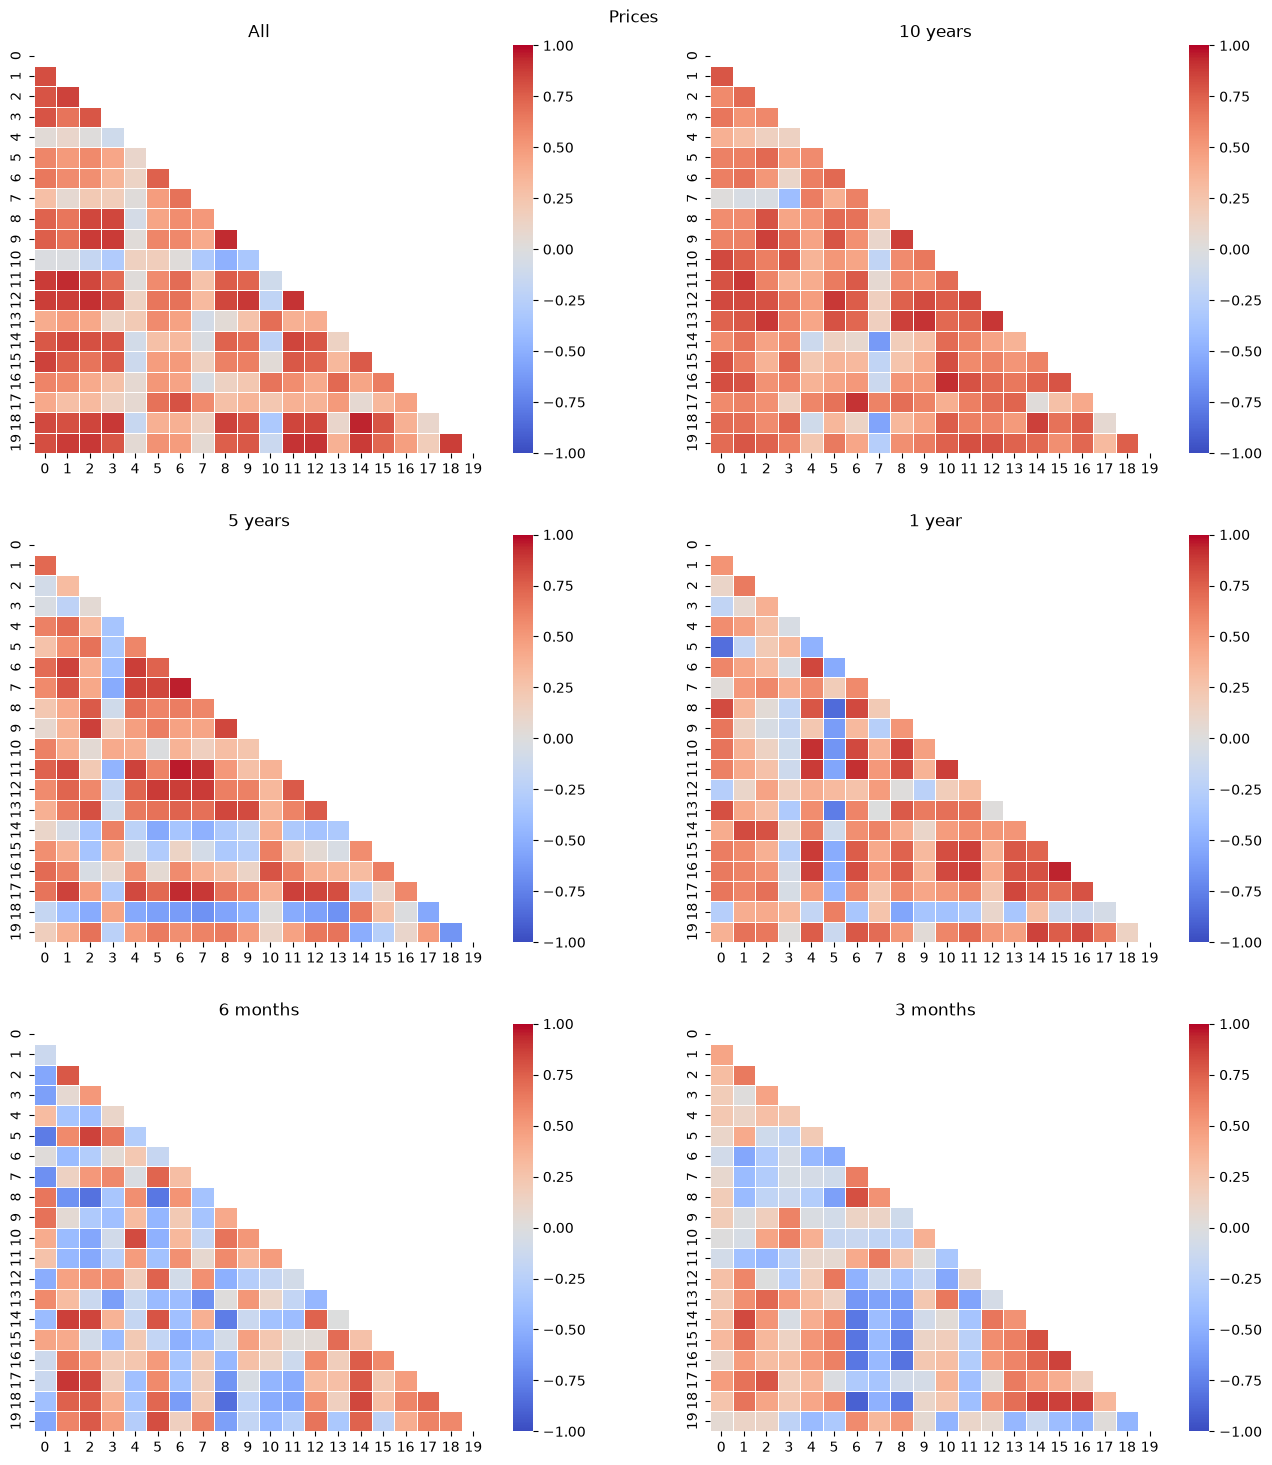

In [155]:
#### Historic Correlation - Prices 
num_cols = 2
num_rows = 3
fig, axs = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(WIDTH * num_cols, HEIGHT * num_rows))
axs_arr = [axs[0,0], axs[0,1], axs[1,0], axs[1,1], axs[2,0], axs[2,1]]
for i, period_corr in enumerate(np_prices_hist_corr):
    mask = np.zeros_like(period_corr, dtype=np.bool)
    mask[np.triu_indices_from(mask)] = True
    sns.heatmap(
        period_corr,
        ax = axs_arr[i],
        annot=False,
        cmap='coolwarm',
        linewidths=0.5,
        vmin=-1, vmax=1,
        mask=mask
    )
    axs_arr[i].set_title(f'{periods[i]}')
    # axs_arr[i].set_xticklabels(stocks)
fig.suptitle(f'Prices', y=0.9)
plt.show()

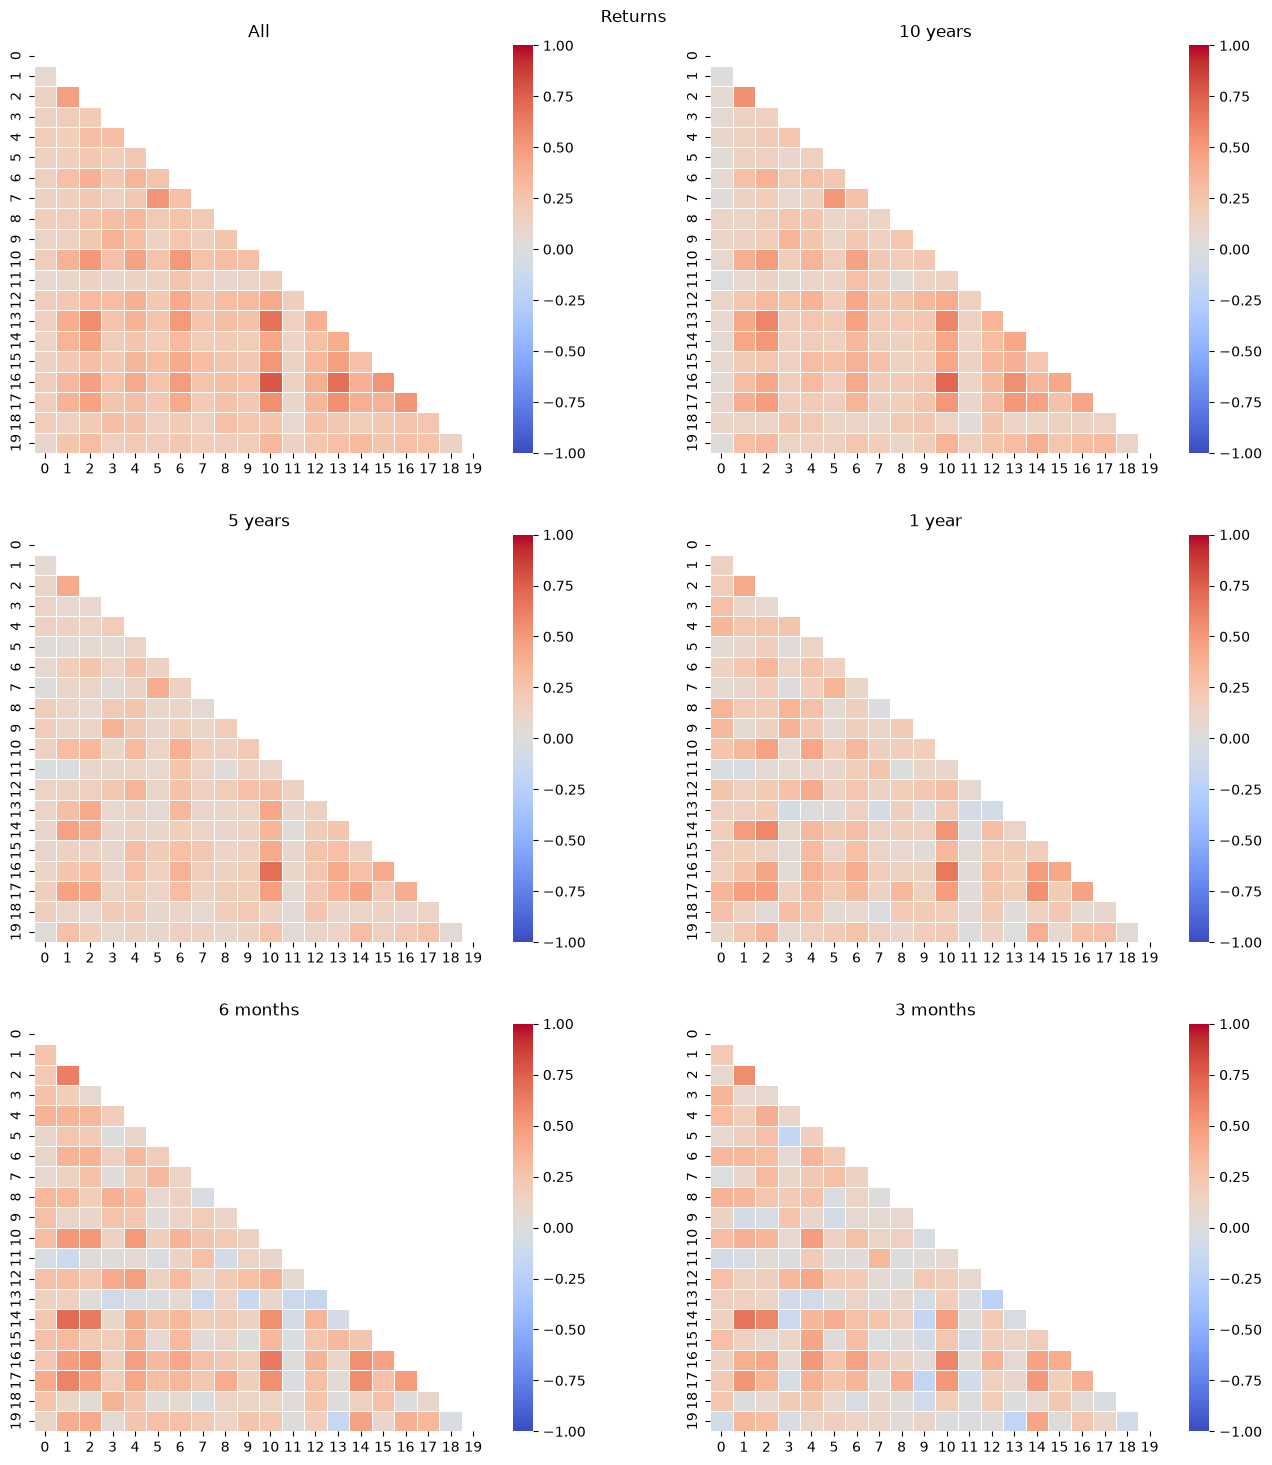

In [156]:
#### Historic Correlation - Returns 
num_cols = 2
num_rows = 3
fig, axs = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(WIDTH * num_cols, HEIGHT * num_rows))
axs_arr = [axs[0,0], axs[0,1], axs[1,0], axs[1,1], axs[2,0], axs[2,1]]
for i, period_corr in enumerate(np_returns_hist_corr):
    mask = np.zeros_like(period_corr, dtype=np.bool)
    mask[np.triu_indices_from(mask)] = True
    sns.heatmap(
        period_corr,
        ax = axs_arr[i],
        annot=False,
        cmap='coolwarm',
        linewidths=0.5,
        vmin=-1, vmax=1,
        mask=mask
    )
    axs_arr[i].set_title(f'{periods[i]}')
    # axs_arr[i].set_xticklabels(stocks)
fig.suptitle(f'Returns', y=0.9)
plt.show()

In [157]:
#### Benchmarking
### Reading data
df_splac = pd.read_csv(
    f'{data_path}/raw_splac.csv',
    parse_dates=['Date'],
    index_col='Date'
)

### Calculating Cum returns
## Log returns
df_lr = np.log(df_splac['Close']/df_splac['Close'].shift(1))
## Aggregating across time
df_cumsum = df_lr.cumsum(axis=0)
## Transforming to simple returns
df_cumret = np.exp(df_cumsum) - 1

### Alternative Cum returns
## Simple returns
simpleR = (df_splac['Close']/df_splac['Close'].shift(1)) - 1
## Agregating across time
df_cr = (1+simpleR).cumprod() - 1

### Visual
plt.figure()
plt.plot(df_cumret)
# plt.plot(df_cr)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'Data/raw_splac.csv'